<a href="https://colab.research.google.com/github/joshuammelcrak-art/Estocasticos/blob/main/Descomposici%C3%B3nCan%C3%B3nica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Descomposición Canónica

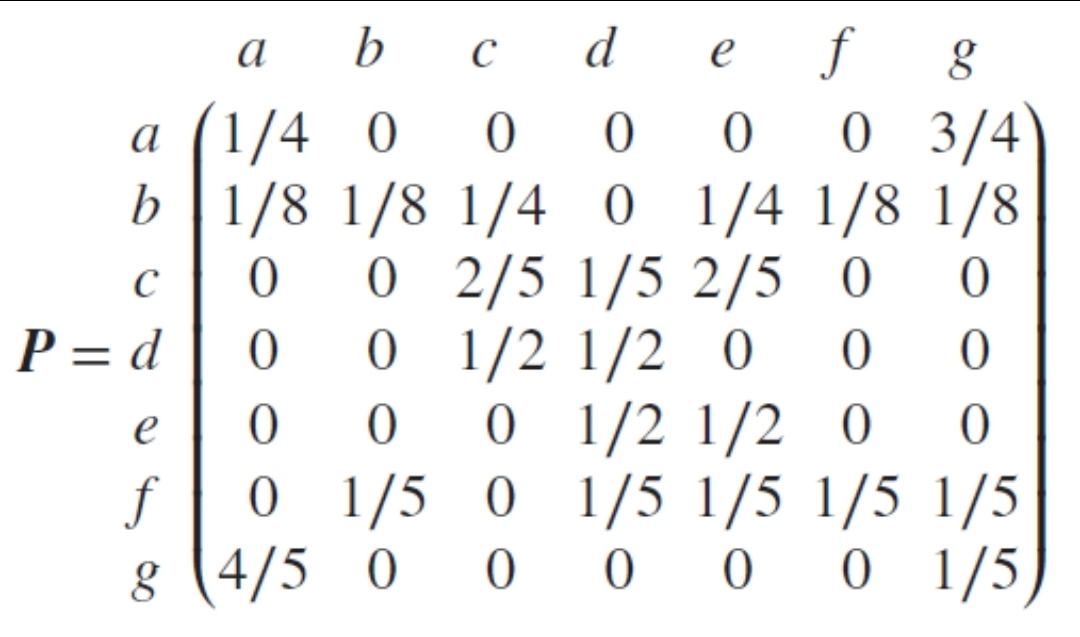

1. Escriba la matriz P de la imagen anexa y dibuje su diagrama de transiciones.

In [19]:
import numpy as np
import pandas as pd

# Estados
estados = ['a','b','c','d','e','f','g']

# Matriz P
P = np.array([
    [1/4, 0,   0,   0,   0,   0,   3/4],
    [1/8, 1/8, 1/4, 0,   1/4, 1/8, 1/8],
    [0,   0,   2/5, 1/5, 2/5, 0,   0],
    [0,   0,   1/2, 1/2, 0,   0,   0],
    [0,   0,   0,   1/2, 1/2, 0,   0],
    [0,   1/5, 0,   1/5, 1/5, 1/5, 1/5],
    [4/5, 0,   0,   0,   0,   0,   1/5]
])


       a      b     c    d     e      f      g
a  0.250  0.000  0.00  0.0  0.00  0.000  0.750
b  0.125  0.125  0.25  0.0  0.25  0.125  0.125
c  0.000  0.000  0.40  0.2  0.40  0.000  0.000
d  0.000  0.000  0.50  0.5  0.00  0.000  0.000
e  0.000  0.000  0.00  0.5  0.50  0.000  0.000
f  0.000  0.200  0.00  0.2  0.20  0.200  0.200
g  0.800  0.000  0.00  0.0  0.00  0.000  0.200


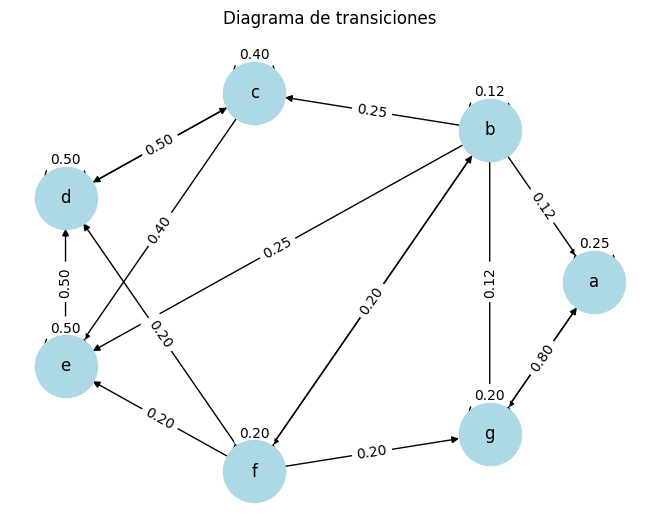

In [20]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

# Agregar nodos
G.add_nodes_from(estados)

# Agregar aristas con probabilidades
for i, origen in enumerate(estados):
    for j, destino in enumerate(estados):
        if P[i, j] > 0:
            G.add_edge(origen, destino, weight=P[i, j])

# Posiciones de los nodos
pos = nx.circular_layout(G)

# Dibujar nodos
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2000)

# Etiquetas de las aristas (probabilidades)
labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)

plt.title("Diagrama de transiciones")
plt.show()

In [21]:
import networkx as nx

G = nx.DiGraph()

# Agregar aristas
for i, origen in enumerate(estados):
    for j, destino in enumerate(estados):
        if P[i, j] > 0:
            G.add_edge(origen, destino)

# Componentes fuertemente conexas
clases = list(nx.strongly_connected_components(G))
print(clases)

[{'a', 'g'}, {'c', 'e', 'd'}, {'b', 'f'}]


Se define la matriz de transición P asociada a una cadena de Markov con espacio de estados:

$$ S={a,b,c,d,e,f,g} $$

La matriz P se construyó utilizando arreglos de numpy, donde cada entrada $P_{
ij}$ representa la probabilidad de transición del estado $i$ al estado $j$.

Posteriormente, se generó el diagrama de transiciones mediante la librería networkx, representando:


*   Cada estado como un nodo
*   Cada transición con probabilidad positiva como una arista dirigida
*   Las probabilidades como etiquetas en las aristas

Este diagrama permite visualizar de manera clara la estructura de la cadena y las conexiones entre estados.

2. Determine si la matriz tiene o no distribución límite.

In [29]:
import networkx as nx

# Crear grafo
G = nx.DiGraph()

for i, origen in enumerate(estados):
    for j, destino in enumerate(estados):
        if P[i, j] > 0:
            G.add_edge(origen, destino)

# Clases de comunicación
clases = list(nx.strongly_connected_components(G))

print("Clases de comunicación:")
for c in clases:
    print(c)

# Detectar clases cerradas
clases_cerradas = []
for c in clases:
    es_cerrada = True
    for estado in c:
        for vecino in G.successors(estado):
            if vecino not in c:
                es_cerrada = False
    if es_cerrada:
        clases_cerradas.append(c)

print("\nClases cerradas:")
for c in clases_cerradas:
    print(c)

# Conclusión justificada
print("\nNúmero de clases cerradas:", len(clases_cerradas))

if len(clases_cerradas) == 1:
    print("Existe distribución límite única")
else:
    print("No existe distribución límite única porque hay más de una clase cerrada")

Clases de comunicación:
{'a', 'g'}
{'c', 'e', 'd'}
{'b', 'f'}

Clases cerradas:
{'a', 'g'}
{'c', 'e', 'd'}

Número de clases cerradas: 2
No existe distribución límite única porque hay más de una clase cerrada


Para determinar si la cadena posee una distribución límite única, se analizaron sus clases de comunicación.

Utilizando teoría de grafos, se identificaron las componentes fuertemente conexas, obteniendo:

* Clase {a,g}
* Clase {c,d,e}
* Estados individuales {b} y {f}

Posteriormente, se determinó cuáles de estas clases son cerradas, es decir, que no tienen transiciones hacia estados fuera de la clase.

Se encontró que:

* {a,g} es una clase cerrada
* {c,d,e} es una clase cerrada

Mientras que:

$b$ y $f$ son estados transientes, ya que pueden salir hacia otros estados pero no regresar.

Dado que existen dos clases cerradas recurrentes, la cadena no es irreducible, lo que implica que:

No existe una distribución límite única

El comportamiento asintótico depende del estado inicial.

3. Escriba la descomposición canónica de la matriz, determine el límite de la potencia n-esima y compare contra las distribuciones límite de las submatrices.

In [23]:
import numpy as np

# --- 1. Reordenar estados ---
orden = ['b', 'f', 'a', 'g', 'c', 'd', 'e']
idx = [estados.index(s) for s in orden]

P_can = P[np.ix_(idx, idx)]

print("Matriz en forma canónica:")
print(P_can)


# --- 2. Identificar bloques ---
# T = (b,f)
# C1 = {a,g}
# C2 = {c,d,e}

T = P_can[0:2, 0:2]
R = P_can[0:2, 2:]
Q1 = P_can[2:4, 2:4]   # clase {a,g}
Q2 = P_can[4:7, 4:7]   # clase {c,d,e}

print("\nBloque T (transientes):\n", T)
print("\nBloque Q1 ({a,g}):\n", Q1)
print("\nBloque Q2 ({c,d,e}):\n", Q2)


# --- 3. Distribuciones estacionarias de cada clase cerrada ---

def estacionaria(Q):
    eigvals, eigvecs = np.linalg.eig(Q.T)
    idx = np.argmin(np.abs(eigvals - 1))
    v = np.real(eigvecs[:, idx])
    return v / np.sum(v)

pi1 = estacionaria(Q1)
pi2 = estacionaria(Q2)

print("\nDistribución estacionaria clase {a,g}:", pi1)
print("Distribución estacionaria clase {c,d,e}:", pi2)


# --- 4. Aproximar límite de P^n ---
P_n = np.linalg.matrix_power(P, 100)  # n grande



Matriz en forma canónica:
[[0.125 0.125 0.125 0.125 0.25  0.    0.25 ]
 [0.2   0.2   0.    0.2   0.    0.2   0.2  ]
 [0.    0.    0.25  0.75  0.    0.    0.   ]
 [0.    0.    0.8   0.2   0.    0.    0.   ]
 [0.    0.    0.    0.    0.4   0.2   0.4  ]
 [0.    0.    0.    0.    0.5   0.5   0.   ]
 [0.    0.    0.    0.    0.    0.5   0.5  ]]

Bloque T (transientes):
 [[0.125 0.125]
 [0.2   0.2  ]]

Bloque Q1 ({a,g}):
 [[0.25 0.75]
 [0.8  0.2 ]]

Bloque Q2 ({c,d,e}):
 [[0.4 0.2 0.4]
 [0.5 0.5 0. ]
 [0.  0.5 0.5]]

Distribución estacionaria clase {a,g}: [0.51612903 0.48387097]
Distribución estacionaria clase {c,d,e}: [0.33333333 0.4        0.26666667]


Se reordenaron los estados para obtener la forma canónica de la matriz:

\begin{equation} P =
\begin{pmatrix}
T & R \\
0 & Q
\end{pmatrix}
\end{equation}

donde:

* T: submatriz de estados transientes (b,f)
* R: transiciones de estados transientes a recurrentes
* Q: submatriz de estados recurrentes

La matriz Q se descompone en dos bloques correspondientes a las clases cerradas:

* $Q_1$ para {a,g}
* $Q_2$ para {c,d,e}

### Distribuciones estacionarias

Se calcularon las distribuciones estacionarias de cada submatriz resolviendo:

$$πQ=π$$

obteniendo:

* Para {a,g}: $$π_1≈(0.5161,0.4839) $$
	​
* Para {c,d,e}: $$ π_2≈(0.3333,0.4000,0.2667) $$

### Límite de P^n

Se aproximó la matriz P^n para valores grandes de n, observando que:

* Las filas correspondientes a estados transientes convergen hacia las clases recurrentes
* Las filas dentro de cada clase cerrada convergen a su respectiva distribución estacionaria

Esto confirma que:

* No existe un único límite global
* El límite depende de la clase recurrente alcanzada

4. Escriba un programa que encuentre la descomposición canónica de una matriz dada.

In [26]:
import numpy as np
import networkx as nx

# --- MATRIZ ORIGINAL ---
estados = ['a','b','c','d','e','f','g']

P = np.array([
    [1/4, 0,   0,   0,   0,   0,   3/4],
    [1/8, 1/8, 1/4, 0,   1/4, 1/8, 1/8],
    [0,   0,   2/5, 1/5, 2/5, 0,   0],
    [0,   0,   1/2, 1/2, 0,   0,   0],
    [0,   0,   0,   1/2, 1/2, 0,   0],
    [0,   1/5, 0,   1/5, 1/5, 1/5, 1/5],
    [4/5, 0,   0,   0,   0,   0,   1/5]
])


# --- FUNCIÓN ---
def descomposicion_canonica(P, estados=None):
    n = P.shape[0]

    if estados is None:
        estados = list(range(n))

    G = nx.DiGraph()
    for i in range(n):
        for j in range(n):
            if P[i, j] > 0:
                G.add_edge(i, j)

    clases = list(nx.strongly_connected_components(G))

    cerradas = []
    transientes = []

    for c in clases:
        es_cerrada = True
        for i in c:
            for j in G.successors(i):
                if j not in c:
                    es_cerrada = False
        if es_cerrada:
            cerradas.append(sorted(list(c)))
        else:
            transientes.extend(list(c))

    transientes = sorted(transientes)

    nuevo_orden = transientes.copy()
    for c in cerradas:
        nuevo_orden.extend(c)

    P_can = P[np.ix_(nuevo_orden, nuevo_orden)]

    t = len(transientes)
    T = P_can[:t, :t]
    R = P_can[:t, t:]
    Q = P_can[t:, t:]

    return {
        "nuevo_orden": [estados[i] for i in nuevo_orden],
        "transientes": [estados[i] for i in transientes],
        "clases_cerradas": [[estados[i] for i in c] for c in cerradas],
        "P_can": P_can,
        "T": T,
        "R": R,
        "Q": Q
    }


# --- EJECUCIÓN ---
res = descomposicion_canonica(P, estados)

print("Nuevo orden de estados:", res["nuevo_orden"])
print("Estados transientes:", res["transientes"])
print("Clases cerradas:", res["clases_cerradas"])

print("\nMatriz canónica:\n", res["P_can"])
print("\nBloque T:\n", res["T"])
print("\nBloque R:\n", res["R"])
print("\nBloque Q:\n", res["Q"])

Nuevo orden de estados: ['b', 'f', 'a', 'g', 'c', 'd', 'e']
Estados transientes: ['b', 'f']
Clases cerradas: [['a', 'g'], ['c', 'd', 'e']]

Matriz canónica:
 [[0.125 0.125 0.125 0.125 0.25  0.    0.25 ]
 [0.2   0.2   0.    0.2   0.    0.2   0.2  ]
 [0.    0.    0.25  0.75  0.    0.    0.   ]
 [0.    0.    0.8   0.2   0.    0.    0.   ]
 [0.    0.    0.    0.    0.4   0.2   0.4  ]
 [0.    0.    0.    0.    0.5   0.5   0.   ]
 [0.    0.    0.    0.    0.    0.5   0.5  ]]

Bloque T:
 [[0.125 0.125]
 [0.2   0.2  ]]

Bloque R:
 [[0.125 0.125 0.25  0.    0.25 ]
 [0.    0.2   0.    0.2   0.2  ]]

Bloque Q:
 [[0.25 0.75 0.   0.   0.  ]
 [0.8  0.2  0.   0.   0.  ]
 [0.   0.   0.4  0.2  0.4 ]
 [0.   0.   0.5  0.5  0.  ]
 [0.   0.   0.   0.5  0.5 ]]


Se implementó una función en Python que, dada una matriz de transición:

1. Construye el grafo asociado
2. Determina las clases de comunicación
3. Identifica estados transientes y clases cerradas
4. Reordena la matriz en forma canónica
5. Extrae los bloques T, R y Q

Este programa permite analizar de manera general cualquier cadena de Markov finita.

### Conclusión

* La cadena no es irreducible, ya que presenta múltiples clases cerradas
* Existen estados transientes que eventualmente desaparecen del sistema
* Cada clase cerrada posee su propia distribución estacionaria
* No existe una distribución límite única para toda la cadena
* La descomposición canónica permite entender claramente la estructura y comportamiento asintótico del sistema